# Fase 4 — Formulación y optimización híbrida del CVRP

En esta fase se transforma la red preparada en las fases anteriores en un problema de **ruteo de vehículos con capacidad** (*Capacitated Vehicle Routing Problem*, CVRP).

La instancia conserva las decisiones ya validadas:

- `DC00` es el **Almacén Especializado de Medicamentos de la RIS Tayacaja**, ubicado en Pampas.
- Las siete IPRESS de la Microrred Colcabamba son los destinos.
- El costo principal es la **distancia por carretera** de OSRM/OpenStreetMap.
- Haversine no participa en la optimización.
- La demanda es sintética y, por tanto, la capacidad vehicular de esta fase también se declara como un supuesto de simulación.

Se comparan tres enfoques:

1. vecino más cercano con restricción de capacidad;
2. ahorros de Clarke–Wright;
3. solución exacta por programación dinámica.

Finalmente se construye una prueba de concepto de **Grover** sobre los planes factibles. El circuito demuestra amplificación de amplitud, pero no constituye evidencia de ventaja cuántica en una instancia de solo siete destinos.


## Entradas y salidas

| Tipo | Archivo | Uso |
|---|---|---|
| Entrada | `data/optimization/optimization_instance.csv` | Nodos, roles y demanda seleccionada |
| Entrada principal | `data/optimization/distance_matrix_with_source.csv` | Kilómetros por carretera |
| Entrada auxiliar | `data/optimization/duration_matrix_with_source.csv` | Minutos estimados |
| Salida | `data/results/cvrp_solution_routes.csv` | Resumen de rutas |
| Salida | `data/results/cvrp_solution_stops.csv` | Secuencia de visitas |
| Salida | `data/results/cvrp_candidate_plans.csv` | Planes factibles para la prueba de Grover |
| Salida | `data/results/method_comparison.csv` | Comparación de algoritmos |
| Salida | `data/results/capacity_sensitivity.csv` | Sensibilidad a la capacidad |
| Salida visual | `outputs/figures/cvrp_*.png` | Gráficos de la fase |
| Salida visual | `outputs/maps/cvrp_optimal_routes.html` | Mapa interactivo de rutas viales |


In [1]:
from pathlib import Path
from functools import lru_cache
from itertools import permutations
from urllib.parse import urlencode
from urllib.request import urlopen
import json
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)

def find_repo_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "data" / "optimization").exists():
            return candidate
        nested = candidate / "qmed-colcabamba"
        if (nested / "data" / "optimization").exists():
            return nested
    raise FileNotFoundError(
        "No se encontró la raíz de qmed-colcabamba. "
        "Ejecuta el notebook desde el repositorio."
    )

REPO_ROOT = find_repo_root()
OPT_DIR = REPO_ROOT / "data" / "optimization"
RESULTS_DIR = REPO_ROOT / "data" / "results"
FIGURES_DIR = REPO_ROOT / "outputs" / "figures"
MAPS_DIR = REPO_ROOT / "outputs" / "maps"

for directory in [RESULTS_DIR, FIGURES_DIR, MAPS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

INSTANCE_PATH = OPT_DIR / "optimization_instance.csv"
DISTANCE_PATH = OPT_DIR / "distance_matrix_with_source.csv"
DURATION_PATH = OPT_DIR / "duration_matrix_with_source.csv"

# Supuesto de simulación: debe sustituirse por capacidad operativa real.
VEHICLE_CAPACITY_UNITS = 75
RETURN_TO_SOURCE = True
ALLOW_SPLIT_DELIVERIES = False
OBJECTIVE = "ROAD_DISTANCE_KM"
OSRM_ROUTE_URL = "https://router.project-osrm.org/route/v1/driving"

print(f"Raíz del repositorio: {REPO_ROOT}")


Raíz del repositorio: O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte


## 1. Carga y controles de consistencia

La matriz vial puede ser asimétrica: viajar de $i$ a $j$ no tiene que tomar exactamente lo mismo que regresar de $j$ a $i$. Por eso el código conserva la dirección de cada arco y no fuerza simetría.


In [2]:
instance = pd.read_csv(INSTANCE_PATH, encoding="utf-8-sig")
distance_km = pd.read_csv(
    DISTANCE_PATH, index_col=0, encoding="utf-8-sig"
)
duration_min = pd.read_csv(
    DURATION_PATH, index_col=0, encoding="utf-8-sig"
)

instance["NODE_ID"] = instance["NODE_ID"].astype(str)
distance_km.index = distance_km.index.astype(str)
distance_km.columns = distance_km.columns.astype(str)
duration_min.index = duration_min.index.astype(str)
duration_min.columns = duration_min.columns.astype(str)

required_columns = {
    "NODE_ID", "NOMBRE", "LATITUD", "LONGITUD", "ROLE", "DEMAND_UNITS"
}
missing_columns = required_columns - set(instance.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas en la instancia: {missing_columns}")

node_ids = instance["NODE_ID"].tolist()
if distance_km.index.tolist() != node_ids or distance_km.columns.tolist() != node_ids:
    raise ValueError("La matriz de distancias no sigue el orden de la instancia.")
if duration_min.index.tolist() != node_ids or duration_min.columns.tolist() != node_ids:
    raise ValueError("La matriz de tiempos no sigue el orden de la instancia.")
if distance_km.isna().any().any() or duration_min.isna().any().any():
    raise ValueError("Las matrices contienen valores faltantes.")
if (distance_km.to_numpy() < 0).any() or (duration_min.to_numpy() < 0).any():
    raise ValueError("Las matrices contienen costos negativos.")

source_rows = instance.loc[instance["ROLE"].eq("SOURCE")]
if len(source_rows) != 1:
    raise ValueError("Debe existir exactamente un nodo fuente.")

SOURCE_ID = source_rows.iloc[0]["NODE_ID"]
SOURCE_NAME = source_rows.iloc[0]["NOMBRE"]
customers = instance.loc[instance["ROLE"].eq("DESTINATION"), "NODE_ID"].tolist()
demand = instance.set_index("NODE_ID")["DEMAND_UNITS"].astype(int).to_dict()
name_by_id = instance.set_index("NODE_ID")["NOMBRE"].to_dict()

if SOURCE_ID != "DC00" or "TAYACAJA" not in SOURCE_NAME.upper():
    raise ValueError(
        "La fuente no corresponde al almacén de la RIS Tayacaja."
    )
if demand[SOURCE_ID] != 0:
    raise ValueError("El nodo fuente debe tener demanda cero.")
if any(demand[node] <= 0 for node in customers):
    raise ValueError("Todos los destinos deben tener demanda positiva.")

audit = pd.DataFrame(
    {
        "CONTROL": [
            "Fuente logística",
            "Número de destinos",
            "Demanda total",
            "Matriz objetivo",
            "Capacidad simulada",
            "Entregas divididas",
        ],
        "VALOR": [
            SOURCE_NAME,
            len(customers),
            sum(demand[node] for node in customers),
            "OSRM por carretera (km)",
            VEHICLE_CAPACITY_UNITS,
            "No" if not ALLOW_SPLIT_DELIVERIES else "Sí",
        ],
    }
)
display(audit)
display(
    instance[
        ["NODE_ID", "NOMBRE", "CATEGORIA", "ROLE", "DEMAND_UNITS"]
    ]
)


,CONTROL,VALOR
0,Fuente logística,ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA RIS TAYACAJA
1,Número de destinos,7
2,Demanda total,184
3,Matriz objetivo,OSRM por carretera (km)
4,Capacidad simulada,75
5,Entregas divididas,No


,NODE_ID,NOMBRE,CATEGORIA,ROLE,DEMAND_UNITS
0,DC00,ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA RIS TAYACAJA,CENTRO LOGÍSTICO,SOURCE,0
1,IP01,COLCABAMBA,I-4,DESTINATION,36
2,IP02,CARPAPATA,I-2,DESTINATION,27
3,IP03,POCCYACC,I-1,DESTINATION,22
4,IP04,OCORO,I-2,DESTINATION,27
5,IP05,TOCAS,I-2,DESTINATION,28
6,IP06,CHACHAS,I-1,DESTINATION,22
7,IP07,RANRA,I-1,DESTINATION,22


## 2. Supuestos operativos

La demanda total es $D=\sum_i q_i$. Si cada vehículo tiene capacidad $Q$, una cota inferior del número de rutas es

$$K_{\min}=\left\lceil\frac{D}{Q}\right\rceil.$$

El valor $Q=75$ no procede de una ficha técnica: es un parámetro demostrativo expresado en las mismas **unidades equivalentes** de la demanda simulada. Se verifica que cada entrega individual cabe en un vehículo y posteriormente se analiza la sensibilidad respecto de $Q$.


In [3]:
total_demand = sum(demand[node] for node in customers)
lower_bound_vehicles = math.ceil(total_demand / VEHICLE_CAPACITY_UNITS)

if max(demand[node] for node in customers) > VEHICLE_CAPACITY_UNITS:
    raise ValueError(
        "Existe una demanda individual mayor que la capacidad; "
        "serían necesarias entregas divididas."
    )

capacity_summary = pd.DataFrame(
    {
        "PARÁMETRO": [
            "Demanda total",
            "Capacidad por vehículo",
            "Cota inferior de vehículos",
            "Capacidad total de la flota mínima",
            "Holgura agregada",
        ],
        "VALOR": [
            total_demand,
            VEHICLE_CAPACITY_UNITS,
            lower_bound_vehicles,
            lower_bound_vehicles * VEHICLE_CAPACITY_UNITS,
            lower_bound_vehicles * VEHICLE_CAPACITY_UNITS - total_demand,
        ],
        "UNIDAD": [
            "unidades equivalentes",
            "unidades equivalentes",
            "vehículos/rutas",
            "unidades equivalentes",
            "unidades equivalentes",
        ],
    }
)
display(capacity_summary)


,PARÁMETRO,VALOR,UNIDAD
0,Demanda total,184,unidades equivalentes
1,Capacidad por vehículo,75,unidades equivalentes
2,Cota inferior de vehículos,3,vehículos/rutas
3,Capacidad total de la flota mínima,225,unidades equivalentes
4,Holgura agregada,41,unidades equivalentes


## 3. Formulación matemática del CVRP

Sean $V=\{0,1,\dots,n\}$ los nodos, $C=V\setminus\{0\}$ los destinos y $K$ los vehículos. El nodo $0$ representa el almacén de Tayacaja. Los parámetros son:

- $c_{ij}$: kilómetros viales desde $i$ hasta $j$;
- $q_i$: demanda del destino $i$;
- $Q$: capacidad de un vehículo.

Definimos $x_{ijk}=1$ si el vehículo $k$ recorre el arco $i\rightarrow j$, y $y_{ik}=1$ si atiende al destino $i$.

La función objetivo es

$$\min \sum_{k\in K}\sum_{i\in V}\sum_{\substack{j\in V\\\\j\neq i}}c_{ij}x_{ijk}.$$

Sujeta a:

$$\sum_{k\in K} y_{ik}=1 \qquad \forall i\in C,$$

$$\sum_{i\in V}x_{ijk}=y_{jk},\qquad
\sum_{j\in V}x_{ijk}=y_{ik},$$

$$\sum_{i\in C}q_i y_{ik}\le Q \qquad \forall k\in K,$$

además de salida y retorno al almacén y restricciones de eliminación de subciclos.

Para el piloto de siete destinos se usa una forma exacta equivalente. Primero se calcula $C(S)$, el mejor recorrido cerrado para cada subconjunto factible $S$. Luego:

$$F(S,k)=\min_{\substack{T\subseteq S\\\\q(T)\le Q}}
\left[C(T)+F(S\setminus T,k-1)\right].$$

Este método es exacto para la instancia pequeña, pero su costo crece exponencialmente; funciona aquí como **verdad de referencia**, no como solución escalable nacional.


In [4]:
def route_metrics(route):
    distance = sum(
        float(distance_km.loc[a, b]) for a, b in zip(route, route[1:])
    )
    duration = sum(
        float(duration_min.loc[a, b]) for a, b in zip(route, route[1:])
    )
    return distance, duration


def build_route_catalog(capacity):
    catalog = {}
    n = len(customers)

    for mask in range(1, 1 << n):
        subset = [
            customers[i] for i in range(n) if (mask >> i) & 1
        ]
        load = sum(demand[node] for node in subset)
        if load > capacity:
            continue

        best = None
        for order in permutations(subset):
            route = [SOURCE_ID, *order, SOURCE_ID]
            distance, duration = route_metrics(route)
            candidate = (distance, duration, route)
            if (
                best is None
                or candidate[0] < best[0] - 1e-9
                or (
                    abs(candidate[0] - best[0]) <= 1e-9
                    and candidate[1] < best[1]
                )
            ):
                best = candidate

        catalog[mask] = {
            "load": load,
            "distance_km": best[0],
            "duration_min": best[1],
            "route": best[2],
        }

    return catalog


def solve_exact_cvrp(capacity, required_routes=None):
    catalog = build_route_catalog(capacity)
    full_mask = (1 << len(customers)) - 1

    @lru_cache(maxsize=None)
    def dp(mask, k):
        if mask == 0 and k == 0:
            return 0.0, ()
        if mask == 0 or k == 0:
            return math.inf, ()

        first_bit = mask & -mask
        best_cost, best_partition = math.inf, ()
        subset = mask

        while subset:
            if subset & first_bit and subset in catalog:
                previous_cost, previous_partition = dp(
                    mask ^ subset, k - 1
                )
                candidate_cost = (
                    previous_cost + catalog[subset]["distance_km"]
                )
                if candidate_cost < best_cost - 1e-9:
                    best_cost = candidate_cost
                    best_partition = previous_partition + (subset,)
            subset = (subset - 1) & mask

        return best_cost, best_partition

    lower_bound = math.ceil(
        sum(demand[node] for node in customers) / capacity
    )
    route_counts = (
        [required_routes]
        if required_routes is not None
        else range(lower_bound, len(customers) + 1)
    )

    for route_count in route_counts:
        objective, partition = dp(full_mask, route_count)
        if math.isfinite(objective):
            routes = [catalog[mask] for mask in partition]
            routes.sort(
                key=lambda item: (
                    min(customers.index(node) for node in item["route"][1:-1]),
                    item["distance_km"],
                )
            )
            return {
                "capacity": capacity,
                "route_count": route_count,
                "objective_km": objective,
                "routes": routes,
                "partition": partition,
                "catalog": catalog,
            }

    raise ValueError(
        f"No existe solución factible con capacidad {capacity}."
    )


exact_solution = solve_exact_cvrp(VEHICLE_CAPACITY_UNITS)

route_rows = []
stop_rows = []
for route_number, item in enumerate(exact_solution["routes"], start=1):
    route_id = f"R{route_number:02d}"
    route_rows.append(
        {
            "ROUTE_ID": route_id,
            "VEHICLE_CAPACITY": VEHICLE_CAPACITY_UNITS,
            "LOAD_UNITS": item["load"],
            "UTILIZATION_PCT": 100 * item["load"] / VEHICLE_CAPACITY_UNITS,
            "DISTANCE_KM": item["distance_km"],
            "DURATION_MIN": item["duration_min"],
            "STOPS": len(item["route"]) - 2,
            "ROUTE_NODE_IDS": " -> ".join(item["route"]),
            "ROUTE_NAMES": " -> ".join(
                name_by_id[node] for node in item["route"]
            ),
        }
    )
    for sequence, node in enumerate(item["route"]):
        stop_rows.append(
            {
                "ROUTE_ID": route_id,
                "SEQUENCE": sequence,
                "NODE_ID": node,
                "NOMBRE": name_by_id[node],
                "DELIVERY_UNITS": demand[node],
            }
        )

exact_routes_df = pd.DataFrame(route_rows)
exact_stops_df = pd.DataFrame(stop_rows)

print(
    f"Óptimo exacto: {exact_solution['objective_km']:.2f} km, "
    f"{exact_solution['route_count']} rutas."
)
display(
    exact_routes_df[
        [
            "ROUTE_ID",
            "LOAD_UNITS",
            "UTILIZATION_PCT",
            "DISTANCE_KM",
            "DURATION_MIN",
            "ROUTE_NODE_IDS",
        ]
    ].round(2)
)


Óptimo exacto: 406.68 km, 3 rutas.


,ROUTE_ID,LOAD_UNITS,UTILIZATION_PCT,DISTANCE_KM,DURATION_MIN,ROUTE_NODE_IDS
0,R01,63,84.00,116.60,125.74,DC00 -> IP01 -> IP02 -> DC00
1,R02,72,96.00,176.28,205.06,DC00 -> IP03 -> IP06 -> IP05 -> DC00
2,R03,49,65.33,113.79,129.43,DC00 -> IP04 -> IP07 -> DC00


## 4. Baselines clásicos

- **Vecino más cercano:** desde la posición actual visita el destino vialmente más cercano que todavía cabe en el vehículo.
- **Clarke–Wright:** parte de una ruta independiente por destino y fusiona extremos según el ahorro

$$s_{ij}=c_{0i}+c_{j0}-c_{ij}.$$

Ambos respetan capacidad, retorno a Tayacaja y entrega única. Se comparan contra el óptimo exacto; no se espera que un método cuántico obtenga menos que el óptimo.


,METHOD,ROUTES,TOTAL_DISTANCE_KM,TOTAL_DURATION_MIN,MAX_ROUTE_LOAD,FEASIBLE,GAP_TO_OPTIMUM_PCT,SAVING_VS_SEPARATE_PCT
0,Entregas separadas,7,848.69,901.41,36,True,108.69,0.00
1,Vecino más cercano,3,487.36,550.31,71,True,19.84,42.57
2,Clarke-Wright,3,406.68,460.40,72,True,0.00,52.08
3,Exacto (DP),3,406.68,460.22,72,True,0.00,52.08


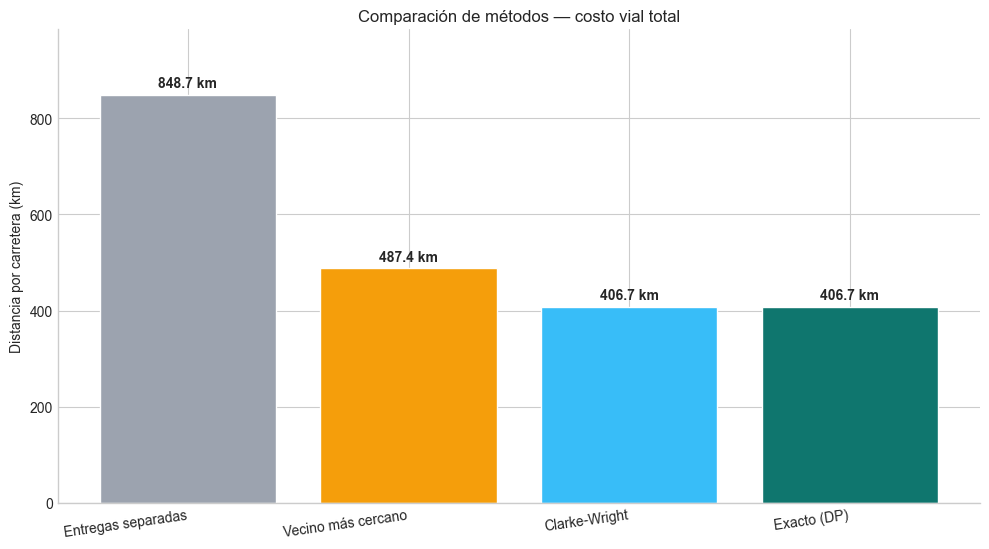

In [5]:
def route_dict_from_nodes(nodes):
    route = [SOURCE_ID, *nodes, SOURCE_ID]
    distance, duration = route_metrics(route)
    return {
        "route": route,
        "load": sum(demand[node] for node in nodes),
        "distance_km": distance,
        "duration_min": duration,
    }


def nearest_neighbor_cvrp(capacity):
    unvisited = set(customers)
    routes = []

    while unvisited:
        current = SOURCE_ID
        load = 0
        route_nodes = []

        while True:
            feasible = [
                node
                for node in unvisited
                if load + demand[node] <= capacity
            ]
            if not feasible:
                break
            next_node = min(
                feasible,
                key=lambda node: (
                    float(distance_km.loc[current, node]),
                    node,
                ),
            )
            route_nodes.append(next_node)
            unvisited.remove(next_node)
            load += demand[next_node]
            current = next_node

        routes.append(route_dict_from_nodes(route_nodes))

    return routes


def clarke_wright_cvrp(capacity):
    routes = [[node] for node in customers]

    while True:
        best_merge = None

        for first in range(len(routes)):
            for second in range(first + 1, len(routes)):
                load = sum(
                    demand[node]
                    for node in routes[first] + routes[second]
                )
                if load > capacity:
                    continue

                for left in [routes[first], list(reversed(routes[first]))]:
                    for right in [routes[second], list(reversed(routes[second]))]:
                        merged = left + right
                        before = (
                            route_dict_from_nodes(routes[first])["distance_km"]
                            + route_dict_from_nodes(routes[second])["distance_km"]
                        )
                        after = route_dict_from_nodes(merged)["distance_km"]
                        saving = before - after
                        candidate = (saving, first, second, merged)
                        if (
                            best_merge is None
                            or candidate[0] > best_merge[0] + 1e-9
                        ):
                            best_merge = candidate

        if best_merge is None or best_merge[0] <= 1e-9:
            break

        _, first, second, merged = best_merge
        routes = [
            route
            for index, route in enumerate(routes)
            if index not in {first, second}
        ] + [merged]

    return [route_dict_from_nodes(route) for route in routes]


nearest_routes = nearest_neighbor_cvrp(VEHICLE_CAPACITY_UNITS)
savings_routes = clarke_wright_cvrp(VEHICLE_CAPACITY_UNITS)

separate_routes = [route_dict_from_nodes([node]) for node in customers]

def summarize_method(method, routes):
    return {
        "METHOD": method,
        "ROUTES": len(routes),
        "TOTAL_DISTANCE_KM": sum(item["distance_km"] for item in routes),
        "TOTAL_DURATION_MIN": sum(item["duration_min"] for item in routes),
        "MAX_ROUTE_LOAD": max(item["load"] for item in routes),
        "FEASIBLE": all(
            item["load"] <= VEHICLE_CAPACITY_UNITS for item in routes
        ),
    }

comparison = pd.DataFrame(
    [
        summarize_method("Entregas separadas", separate_routes),
        summarize_method("Vecino más cercano", nearest_routes),
        summarize_method("Clarke-Wright", savings_routes),
        summarize_method("Exacto (DP)", exact_solution["routes"]),
    ]
)
optimum = exact_solution["objective_km"]
comparison["GAP_TO_OPTIMUM_PCT"] = (
    100 * (comparison["TOTAL_DISTANCE_KM"] - optimum) / optimum
)
comparison["SAVING_VS_SEPARATE_PCT"] = (
    100
    * (
        comparison.loc[
            comparison["METHOD"].eq("Entregas separadas"),
            "TOTAL_DISTANCE_KM",
        ].iloc[0]
        - comparison["TOTAL_DISTANCE_KM"]
    )
    / comparison.loc[
        comparison["METHOD"].eq("Entregas separadas"),
        "TOTAL_DISTANCE_KM",
    ].iloc[0]
)

display(comparison.round(2))

fig, ax = plt.subplots(figsize=(10, 5.6))
colors = ["#9CA3AF", "#F59E0B", "#38BDF8", "#0F766E"]
bars = ax.bar(
    comparison["METHOD"],
    comparison["TOTAL_DISTANCE_KM"],
    color=colors,
    edgecolor="white",
)
for bar, value in zip(bars, comparison["TOTAL_DISTANCE_KM"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{value:.1f} km",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
ax.set_title("Comparación de métodos — costo vial total")
ax.set_ylabel("Distancia por carretera (km)")
ax.set_xlabel("")
ax.set_ylim(0, comparison["TOTAL_DISTANCE_KM"].max() * 1.16)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=8, ha="right")
plt.tight_layout()
comparison_figure = FIGURES_DIR / "cvrp_method_comparison.png"
plt.savefig(comparison_figure, dpi=180, bbox_inches="tight")
plt.show()


## 5. Sensibilidad a la capacidad

Como $Q$ es un supuesto, se vuelve explícita su influencia. Para cada capacidad se calcula el número mínimo **factible** de rutas y su distancia óptima. Una caída brusca de kilómetros suele ocurrir cuando una capacidad mayor permite usar un vehículo menos.


,CAPACITY_UNITS,ROUTES,TOTAL_DISTANCE_KM,TOTAL_DEMAND_UNITS,TOTAL_CAPACITY_UNITS,AGGREGATE_SLACK_UNITS,IS_SELECTED
0,55,4,543.71,184,220,36,False
1,60,4,500.95,184,240,56,False
2,65,4,496.72,184,260,76,False
3,70,3,441.92,184,210,26,False
4,75,3,406.68,184,225,41,True
5,80,3,401.48,184,240,56,False
6,90,3,388.14,184,270,86,False
7,100,2,320.38,184,200,16,False
8,120,2,291.92,184,240,56,False
9,184,1,205.62,184,184,0,False


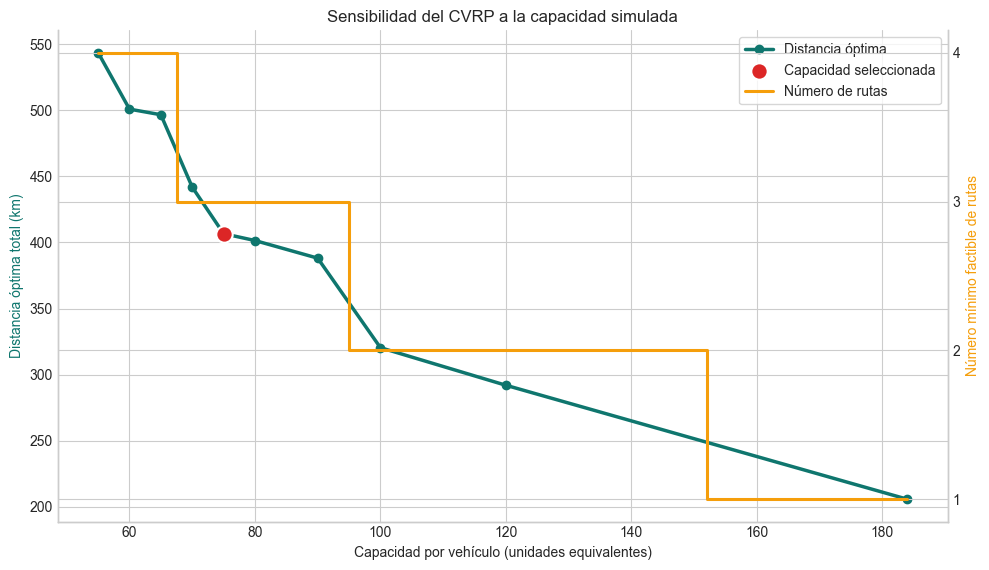

In [6]:
capacity_values = [55, 60, 65, 70, 75, 80, 90, 100, 120, 184]
sensitivity_rows = []

for capacity in capacity_values:
    solution = solve_exact_cvrp(capacity)
    sensitivity_rows.append(
        {
            "CAPACITY_UNITS": capacity,
            "ROUTES": solution["route_count"],
            "TOTAL_DISTANCE_KM": solution["objective_km"],
            "TOTAL_DEMAND_UNITS": total_demand,
            "TOTAL_CAPACITY_UNITS": capacity * solution["route_count"],
            "AGGREGATE_SLACK_UNITS": (
                capacity * solution["route_count"] - total_demand
            ),
            "IS_SELECTED": capacity == VEHICLE_CAPACITY_UNITS,
        }
    )

sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.round(2))

fig, ax_distance = plt.subplots(figsize=(10, 5.8))
ax_routes = ax_distance.twinx()

ax_distance.plot(
    sensitivity["CAPACITY_UNITS"],
    sensitivity["TOTAL_DISTANCE_KM"],
    color="#0F766E",
    marker="o",
    linewidth=2.5,
    label="Distancia óptima",
)
ax_routes.step(
    sensitivity["CAPACITY_UNITS"],
    sensitivity["ROUTES"],
    where="mid",
    color="#F59E0B",
    linewidth=2.2,
    label="Número de rutas",
)
selected_row = sensitivity.loc[sensitivity["IS_SELECTED"]].iloc[0]
ax_distance.scatter(
    [selected_row["CAPACITY_UNITS"]],
    [selected_row["TOTAL_DISTANCE_KM"]],
    s=140,
    color="#DC2626",
    edgecolor="white",
    linewidth=1.5,
    zorder=5,
    label="Capacidad seleccionada",
)
ax_distance.set_title("Sensibilidad del CVRP a la capacidad simulada")
ax_distance.set_xlabel("Capacidad por vehículo (unidades equivalentes)")
ax_distance.set_ylabel("Distancia óptima total (km)", color="#0F766E")
ax_routes.set_ylabel("Número mínimo factible de rutas", color="#F59E0B")
ax_routes.set_yticks(sorted(sensitivity["ROUTES"].unique()))
handles_a, labels_a = ax_distance.get_legend_handles_labels()
handles_b, labels_b = ax_routes.get_legend_handles_labels()
ax_distance.legend(
    handles_a + handles_b,
    labels_a + labels_b,
    loc="upper right",
    frameon=True,
)
ax_distance.spines["top"].set_visible(False)
ax_routes.spines["top"].set_visible(False)
plt.tight_layout()
sensitivity_figure = FIGURES_DIR / "cvrp_capacity_sensitivity.png"
plt.savefig(sensitivity_figure, dpi=180, bbox_inches="tight")
plt.show()


## 6. Selección del algoritmo cuántico

| Algoritmo | Problema para el que fue diseñado | Ajuste al CVRP |
|---|---|---|
| Deutsch–Jozsa | Distinguir funciones constantes y balanceadas | No representa una búsqueda de rutas |
| Bernstein–Vazirani | Recuperar una cadena binaria oculta | No modela costos ni capacidad |
| Simon | Encontrar una periodicidad XOR | No corresponde a la estructura logística |
| Grover | Buscar estados marcados en un espacio no estructurado | Sí puede buscar planes factibles mediante un oráculo |

Por ello se usa **Grover** como prueba de concepto. La estrategia híbrida es:

1. generar particiones de destinos que respetan capacidad;
2. calcular la mejor secuencia vial dentro de cada ruta;
3. codificar cada plan factible con un índice binario;
4. marcar mediante un oráculo el plan que satisface un umbral de costo;
5. amplificar su probabilidad.

Esta descomposición es apropiada para demostrar el algoritmo, pero la generación clásica de candidatos y el uso de un umbral conocido impiden afirmar una ventaja cuántica de extremo a extremo.


In [7]:
def enumerate_feasible_partitions(full_mask, route_count, catalog):
    partitions = []

    def recurse(remaining, routes_left, chosen):
        if routes_left == 0:
            if remaining == 0:
                partitions.append(chosen)
            return
        if remaining == 0:
            return

        first_bit = remaining & -remaining
        subset = remaining
        while subset:
            rest = remaining ^ subset
            if (
                subset & first_bit
                and subset in catalog
                and rest.bit_count() >= routes_left - 1
            ):
                recurse(rest, routes_left - 1, chosen + (subset,))
            subset = (subset - 1) & remaining

    recurse(full_mask, route_count, ())
    return partitions


full_mask = (1 << len(customers)) - 1
feasible_partitions = enumerate_feasible_partitions(
    full_mask,
    exact_solution["route_count"],
    exact_solution["catalog"],
)

candidate_rows = []
for candidate_index, partition in enumerate(feasible_partitions):
    route_items = [
        exact_solution["catalog"][mask] for mask in partition
    ]
    total_distance = sum(item["distance_km"] for item in route_items)
    total_duration = sum(item["duration_min"] for item in route_items)
    candidate_rows.append(
        {
            "QUANTUM_STATE_INDEX": candidate_index,
            "PARTITION_MASKS": "|".join(str(mask) for mask in partition),
            "ROUTES": " || ".join(
                " -> ".join(item["route"]) for item in route_items
            ),
            "LOADS": "|".join(str(item["load"]) for item in route_items),
            "TOTAL_DISTANCE_KM": total_distance,
            "TOTAL_DURATION_MIN": total_duration,
        }
    )

candidates = pd.DataFrame(candidate_rows)
best_candidate_cost = candidates["TOTAL_DISTANCE_KM"].min()
candidates["IS_OPTIMAL"] = np.isclose(
    candidates["TOTAL_DISTANCE_KM"], best_candidate_cost
)
candidates["GAP_TO_BEST_PCT"] = (
    100
    * (candidates["TOTAL_DISTANCE_KM"] - best_candidate_cost)
    / best_candidate_cost
)

n_candidates = len(candidates)
n_qubits = math.ceil(math.log2(n_candidates))
search_space_size = 1 << n_qubits
marked_states = candidates.loc[
    candidates["IS_OPTIMAL"], "QUANTUM_STATE_INDEX"
].astype(int).tolist()

print(
    f"Planes factibles: {n_candidates}; "
    f"registro: {n_qubits} qubits ({search_space_size} estados); "
    f"estados óptimos marcados: {marked_states}."
)
display(
    candidates.sort_values("TOTAL_DISTANCE_KM")
    .head(10)
    .round(3)
)


Planes factibles: 30; registro: 5 qubits (32 estados); estados óptimos marcados: [26].


,QUANTUM_STATE_INDEX,PARTITION_MASKS,ROUTES,LOADS,TOTAL_DISTANCE_KM,TOTAL_DURATION_MIN,IS_OPTIMAL,GAP_TO_BEST_PCT
26,26,3|52|72,DC00 -> IP01 -> IP02 -> DC00 || DC00 -> IP03 -> IP06 -> IP05 -> DC00 || DC00 -> IP04 -> IP07 -> DC00,63|72|49,406.678,460.218,True,0.000
15,15,9|66|52,DC00 -> IP01 -> IP04 -> DC00 || DC00 -> IP07 -> IP02 -> DC00 || DC00 -> IP03 -> IP06 -> IP05 -> DC00,63|49|72,419.644,481.788,False,3.188
9,9,17|38|72,DC00 -> IP05 -> IP01 -> DC00 || DC00 -> IP03 -> IP06 -> IP02 -> DC00 || DC00 -> IP04 -> IP07 -> DC00,64|71|49,420.022,477.130,False,3.281
2,2,65|10|52,DC00 -> IP01 -> IP07 -> DC00 || DC00 -> IP04 -> IP02 -> DC00 || DC00 -> IP03 -> IP06 -> IP05 -> DC00,58|54|72,428.574,491.483,False,5.384
8,8,17|66|44,DC00 -> IP05 -> IP01 -> DC00 || DC00 -> IP07 -> IP02 -> DC00 || DC00 -> IP04 -> IP06 -> IP03 -> DC00,64|49|71,432.988,498.660,False,6.470
11,11,17|10|100,DC00 -> IP05 -> IP01 -> DC00 || DC00 -> IP04 -> IP02 -> DC00 || DC00 -> IP03 -> IP06 -> IP07 -> DC00,64|54|66,441.918,508.395,False,8.665
22,22,5|10|112,DC00 -> IP03 -> IP01 -> DC00 || DC00 -> IP04 -> IP02 -> DC00 || DC00 -> IP07 -> IP06 -> IP05 -> DC00,58|54|72,449.972,519.197,False,10.646
5,5,33|10|84,DC00 -> IP01 -> IP06 -> DC00 || DC00 -> IP04 -> IP02 -> DC00 || DC00 -> IP03 -> IP05 -> IP07 -> DC00,58|54|72,455.087,516.978,False,11.903
28,28,3|20|104,DC00 -> IP01 -> IP02 -> DC00 || DC00 -> IP03 -> IP05 -> DC00 || DC00 -> IP06 -> IP04 -> IP07 -> DC00,63|50|71,461.646,517.018,False,13.516
25,25,3|76|48,DC00 -> IP01 -> IP02 -> DC00 || DC00 -> IP03 -> IP04 -> IP07 -> DC00 || DC00 -> IP06 -> IP05 -> DC00,63|71|50,465.468,518.797,False,14.456


## 7. Simulación de Grover

Con $N=2^n$ estados y $M$ soluciones marcadas:

$$\theta=\arcsin\sqrt{\frac{M}{N}},\qquad
P_r=\sin^2((2r+1)\theta).$$

Se usan aproximadamente

$$r^\star=\left\lfloor\frac{\pi}{4}\sqrt{\frac{N}{M}}\right\rfloor$$

iteraciones. El siguiente bloque simula exactamente el vector de estado: aplica el cambio de fase del oráculo y la reflexión respecto de la media. Los estados de relleno hasta $2^n$ se consideran no marcados.


,METRIC,VALUE
0,Planes factibles,30.000000
1,Qubits del registro,5.000000
2,Estados totales,32.000000
3,Estados marcados,1.000000
4,Iteraciones de Grover,4.000000
5,Estado más probable,26.000000
6,Probabilidad total de éxito,0.999182
7,Costo vial del estado medido,406.678000


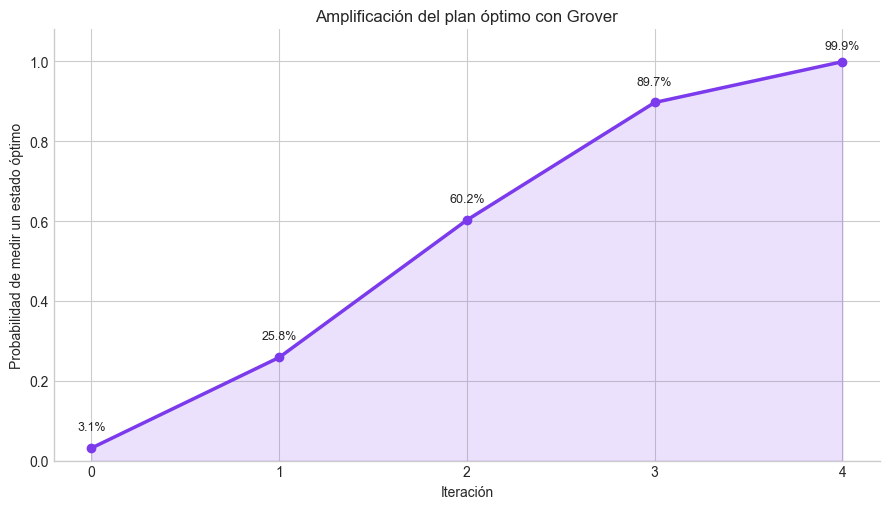

Después de 4 iteraciones, P(óptimo) = 99.92%.


In [8]:
marked_count = len(marked_states)
grover_iterations = max(
    0,
    math.floor(
        math.pi / 4 * math.sqrt(search_space_size / marked_count)
    ),
)

amplitudes = np.ones(search_space_size, dtype=float)
amplitudes /= math.sqrt(search_space_size)
probability_history = [
    float(np.sum(np.abs(amplitudes[marked_states]) ** 2))
]

for _ in range(grover_iterations):
    amplitudes[marked_states] *= -1
    amplitudes = 2 * amplitudes.mean() - amplitudes
    probability_history.append(
        float(np.sum(np.abs(amplitudes[marked_states]) ** 2))
    )

probabilities = np.abs(amplitudes) ** 2
measured_state = int(np.argmax(probabilities))
success_probability = float(probabilities[marked_states].sum())

grover_summary = pd.DataFrame(
    {
        "METRIC": [
            "Planes factibles",
            "Qubits del registro",
            "Estados totales",
            "Estados marcados",
            "Iteraciones de Grover",
            "Estado más probable",
            "Probabilidad total de éxito",
            "Costo vial del estado medido",
        ],
        "VALUE": [
            n_candidates,
            n_qubits,
            search_space_size,
            marked_count,
            grover_iterations,
            measured_state,
            success_probability,
            (
                candidates.loc[
                    candidates["QUANTUM_STATE_INDEX"].eq(measured_state),
                    "TOTAL_DISTANCE_KM",
                ].iloc[0]
                if measured_state < n_candidates
                else np.nan
            ),
        ],
    }
)
display(grover_summary)

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(
    range(len(probability_history)),
    probability_history,
    marker="o",
    linewidth=2.5,
    color="#7C3AED",
)
ax.fill_between(
    range(len(probability_history)),
    probability_history,
    alpha=0.15,
    color="#7C3AED",
)
for iteration, probability in enumerate(probability_history):
    ax.text(
        iteration,
        min(probability + 0.045, 1.03),
        f"{100 * probability:.1f}%",
        ha="center",
        fontsize=9,
    )
ax.set_title("Amplificación del plan óptimo con Grover")
ax.set_xlabel("Iteración")
ax.set_ylabel("Probabilidad de medir un estado óptimo")
ax.set_ylim(0, 1.08)
ax.set_xticks(range(len(probability_history)))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
grover_figure = FIGURES_DIR / "cvrp_grover_amplification.png"
plt.savefig(grover_figure, dpi=180, bbox_inches="tight")
plt.show()

print(
    f"Después de {grover_iterations} iteraciones, "
    f"P(óptimo) = {100 * success_probability:.2f}%."
)


### Circuito opcional con Qiskit

La simulación anterior no requiere dependencias cuánticas. En un entorno con Qiskit, el siguiente bloque construye el mismo circuito para un oráculo de estados marcados. Si Qiskit no está instalado, el notebook continúa sin error.

> El oráculo aquí recibe los índices óptimos obtenidos durante la validación clásica. Para un buscador cuántico completo, el costo y las restricciones tendrían que implementarse reversiblemente dentro del oráculo o mediante Grover Adaptive Search.


In [9]:
try:
    from qiskit import QuantumCircuit
    from qiskit.quantum_info import Statevector
    QISKIT_AVAILABLE = True
except ImportError:
    QISKIT_AVAILABLE = False


def phase_flip_basis_state(circuit, state_index, qubits):
    bit_string = format(state_index, f"0{qubits}b")[::-1]
    zero_qubits = [
        qubit for qubit, bit in enumerate(bit_string) if bit == "0"
    ]
    for qubit in zero_qubits:
        circuit.x(qubit)

    if qubits == 1:
        circuit.z(0)
    else:
        target = qubits - 1
        controls = list(range(qubits - 1))
        circuit.h(target)
        circuit.mcx(controls, target)
        circuit.h(target)

    for qubit in zero_qubits:
        circuit.x(qubit)


if QISKIT_AVAILABLE:
    qc = QuantumCircuit(n_qubits)
    qc.h(range(n_qubits))

    for _ in range(grover_iterations):
        for state in marked_states:
            phase_flip_basis_state(qc, state, n_qubits)

        # Difusor: H O_0 H. La función ya aplica internamente
        # las X necesarias para cambiar la fase de |0...0>.
        qc.h(range(n_qubits))
        phase_flip_basis_state(qc, 0, n_qubits)
        qc.h(range(n_qubits))

    qiskit_probabilities = Statevector.from_instruction(
        qc
    ).probabilities()
    qiskit_success = float(
        qiskit_probabilities[marked_states].sum()
    )
    print(qc.draw(output="text"))
    print(
        "Probabilidad Qiskit del conjunto óptimo: "
        f"{100 * qiskit_success:.2f}%"
    )
    assert abs(qiskit_success - success_probability) < 1e-9
else:
    print(
        "Qiskit no está instalado. La simulación NumPy anterior "
        "ya ejecutó matemáticamente el algoritmo. En Colab puedes "
        "instalar qiskit y volver a ejecutar esta celda."
    )


     ┌───┐┌───┐     ┌───┐┌───┐┌───┐          ┌───┐┌───┐┌───┐          ┌───┐»
q_0: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├»
     ├───┤└───┘  │  ├───┤├───┤└───┘       │  ├───┤├───┤└───┘       │  ├───┤»
q_1: ┤ H ├───────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├────────────■──┤ H ├»
     ├───┤┌───┐  │  ├───┤├───┤┌───┐       │  ├───┤├───┤┌───┐       │  ├───┤»
q_2: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├»
     ├───┤└───┘  │  ├───┤├───┤└───┘       │  ├───┤├───┤└───┘       │  ├───┤»
q_3: ┤ H ├───────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├────────────■──┤ H ├»
     ├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐┌───┐┌─┴─┐├───┤├───┤┌───┐┌───┐┌─┴─┐├───┤»
q_4: ┤ H ├┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├»
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«     ┌───┐┌───┐          ┌───┐┌───┐┌───┐          ┌───┐┌───┐┌───┐          »
«q_0: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├┤ X ├───────■─

## 8. Visualización de las rutas por carretera

La secuencia se obtuvo usando la matriz vial. Para la figura y el mapa se solicita además la geometría de cada recorrido a OSRM. Si el servicio no está disponible, se usa una línea esquemática y se registra explícitamente el *fallback*; el valor objetivo nunca se reemplaza por distancia geodésica.


,ROUTE_ID,MATRIX_DISTANCE_KM,ROUTE_API_DISTANCE_KM,ROUTE_API_DURATION_MIN,GEOMETRY_SOURCE,ABS_DISTANCE_DIFFERENCE_KM
0,R01,116.603,118.946,132.303,OSRM_ROAD,2.344
1,R02,176.285,177.787,209.565,OSRM_ROAD,1.502
2,R03,113.791,114.062,130.260,OSRM_ROAD,0.271


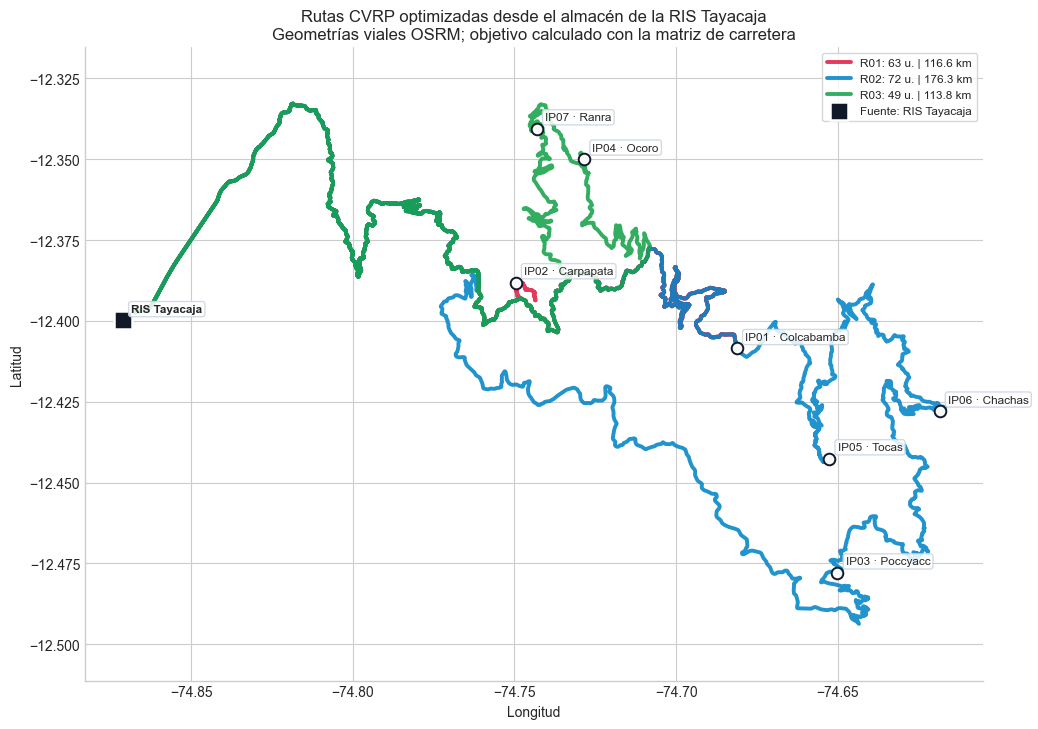

In [10]:
node_lookup = instance.set_index("NODE_ID").to_dict("index")


def osrm_route_geometry(route, retries=2):
    coordinate_string = ";".join(
        f"{node_lookup[node]['LONGITUD']},{node_lookup[node]['LATITUD']}"
        for node in route
    )
    query = urlencode(
        {
            "overview": "full",
            "geometries": "geojson",
            "steps": "false",
        }
    )
    url = f"{OSRM_ROUTE_URL}/{coordinate_string}?{query}"
    last_error = None

    for attempt in range(retries + 1):
        try:
            with urlopen(url, timeout=30) as response:
                payload = json.loads(response.read().decode("utf-8"))
            if payload.get("code") != "Ok":
                raise RuntimeError(payload)
            route_data = payload["routes"][0]
            return {
                "coordinates": route_data["geometry"]["coordinates"],
                "distance_km": route_data["distance"] / 1000,
                "duration_min": route_data["duration"] / 60,
                "geometry_source": "OSRM_ROAD",
            }
        except Exception as error:
            last_error = error
            if attempt < retries:
                time.sleep(1.5 * (attempt + 1))

    fallback = [
        [
            float(node_lookup[node]["LONGITUD"]),
            float(node_lookup[node]["LATITUD"]),
        ]
        for node in route
    ]
    return {
        "coordinates": fallback,
        "distance_km": np.nan,
        "duration_min": np.nan,
        "geometry_source": f"SCHEMATIC_FALLBACK: {type(last_error).__name__}",
    }


route_colors = ["#E11D48", "#0284C7", "#16A34A", "#7C3AED", "#EA580C"]
geometry_rows = []
geojson_features = []

for route_index, item in enumerate(exact_solution["routes"], start=1):
    route_id = f"R{route_index:02d}"
    geometry = osrm_route_geometry(item["route"])
    geometry_rows.append(
        {
            "ROUTE_ID": route_id,
            "MATRIX_DISTANCE_KM": item["distance_km"],
            "ROUTE_API_DISTANCE_KM": geometry["distance_km"],
            "ROUTE_API_DURATION_MIN": geometry["duration_min"],
            "GEOMETRY_SOURCE": geometry["geometry_source"],
        }
    )
    geojson_features.append(
        {
            "type": "Feature",
            "properties": {
                "route_id": route_id,
                "color": route_colors[(route_index - 1) % len(route_colors)],
                "load_units": item["load"],
                "distance_km": round(item["distance_km"], 3),
                "duration_min": round(item["duration_min"], 2),
                "sequence": " → ".join(
                    name_by_id[node] for node in item["route"]
                ),
                "geometry_source": geometry["geometry_source"],
            },
            "geometry": {
                "type": "LineString",
                "coordinates": geometry["coordinates"],
            },
        }
    )

geometry_audit = pd.DataFrame(geometry_rows)
geometry_audit["ABS_DISTANCE_DIFFERENCE_KM"] = (
    geometry_audit["MATRIX_DISTANCE_KM"]
    - geometry_audit["ROUTE_API_DISTANCE_KM"]
).abs()
display(geometry_audit.round(3))

fig, ax = plt.subplots(figsize=(10.5, 7.4))
for feature in geojson_features:
    coordinates = np.asarray(feature["geometry"]["coordinates"])
    props = feature["properties"]
    ax.plot(
        coordinates[:, 0],
        coordinates[:, 1],
        color=props["color"],
        linewidth=2.8,
        alpha=0.88,
        label=(
            f"{props['route_id']}: {props['load_units']} u. | "
            f"{props['distance_km']:.1f} km"
        ),
    )

destinations = instance.loc[instance["ROLE"].eq("DESTINATION")]
source = instance.loc[instance["ROLE"].eq("SOURCE")].iloc[0]
ax.scatter(
    destinations["LONGITUD"],
    destinations["LATITUD"],
    s=70,
    color="#F8FAFC",
    edgecolor="#111827",
    linewidth=1.4,
    zorder=5,
)
ax.scatter(
    [source["LONGITUD"]],
    [source["LATITUD"]],
    s=180,
    marker="s",
    color="#111827",
    edgecolor="white",
    linewidth=1.8,
    zorder=6,
    label="Fuente: RIS Tayacaja",
)

for _, row in instance.iterrows():
    label = (
        "RIS Tayacaja"
        if row["ROLE"] == "SOURCE"
        else f"{row['NODE_ID']} · {row['NOMBRE'].title()}"
    )
    ax.annotate(
        label,
        (row["LONGITUD"], row["LATITUD"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8.5,
        fontweight="bold" if row["ROLE"] == "SOURCE" else "normal",
        bbox=dict(
            boxstyle="round,pad=0.22",
            facecolor="white",
            edgecolor="#CBD5E1",
            alpha=0.86,
        ),
        zorder=7,
    )

ax.set_title(
    "Rutas CVRP optimizadas desde el almacén de la RIS Tayacaja\n"
    "Geometrías viales OSRM; objetivo calculado con la matriz de carretera"
)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend(loc="best", fontsize=8.5, frameon=True)
ax.set_aspect("equal", adjustable="datalim")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
routes_figure = FIGURES_DIR / "cvrp_optimal_routes.png"
plt.savefig(routes_figure, dpi=190, bbox_inches="tight")
plt.show()


In [11]:
geojson_payload = {
    "type": "FeatureCollection",
    "features": geojson_features,
}

map_nodes = instance[
    [
        "NODE_ID",
        "NOMBRE",
        "CATEGORIA",
        "LATITUD",
        "LONGITUD",
        "ROLE",
        "DEMAND_UNITS",
    ]
].to_dict("records")

center_lat = float(instance["LATITUD"].mean())
center_lon = float(instance["LONGITUD"].mean())

leaflet_html = f'''
<!DOCTYPE html>
<html lang="es">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Rutas CVRP Tayacaja–Colcabamba</title>
  <link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css">
  <style>
    html, body, #map {{ height: 100%; margin: 0; }}
    .title {{
      position: absolute; z-index: 999; left: 50px; top: 12px;
      background: rgba(255,255,255,.94); padding: 10px 14px;
      border-radius: 8px; box-shadow: 0 2px 10px rgba(0,0,0,.18);
      font-family: system-ui, sans-serif; max-width: 440px;
    }}
    .title b {{ color: #0F766E; }}
  </style>
</head>
<body>
  <div class="title">
    <b>CVRP: RIS Tayacaja → Microrred Colcabamba</b><br>
    Las líneas siguen la red vial consultada a OSRM.
  </div>
  <div id="map"></div>
  <script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
  <script>
    const map = L.map('map').setView([{center_lat}, {center_lon}], 11);
    L.tileLayer('https://{{s}}.tile.openstreetmap.org/{{z}}/{{x}}/{{y}}.png', {{
      maxZoom: 19,
      attribution: '&copy; OpenStreetMap contributors'
    }}).addTo(map);

    const routes = {json.dumps(geojson_payload, ensure_ascii=False)};
    const nodes = {json.dumps(map_nodes, ensure_ascii=False)};

    const routeLayer = L.geoJSON(routes, {{
      style: feature => ({{
        color: feature.properties.color,
        weight: 5,
        opacity: 0.82
      }}),
      onEachFeature: (feature, layer) => {{
        const p = feature.properties;
        layer.bindPopup(
          `<b>${{p.route_id}}</b><br>` +
          `Carga: ${{p.load_units}} unidades<br>` +
          `Distancia vial: ${{p.distance_km.toFixed(1)}} km<br>` +
          `Tiempo estimado: ${{p.duration_min.toFixed(0)}} min<br>` +
          `${{p.sequence}}`
        );
      }}
    }}).addTo(map);

    nodes.forEach(node => {{
      const isSource = node.ROLE === 'SOURCE';
      const marker = L.circleMarker([node.LATITUD, node.LONGITUD], {{
        radius: isSource ? 10 : 7,
        color: isSource ? '#111827' : '#334155',
        fillColor: isSource ? '#111827' : '#F8FAFC',
        fillOpacity: 1,
        weight: 2
      }}).addTo(map);
      marker.bindPopup(
        `<b>${{node.NOMBRE}}</b><br>` +
        `Nodo: ${{node.NODE_ID}}<br>` +
        `Rol: ${{node.ROLE}}<br>` +
        `Demanda: ${{node.DEMAND_UNITS}} unidades`
      );
    }});

    map.fitBounds(routeLayer.getBounds(), {{padding: [35, 35]}});
    L.control.layers(null, {{'Rutas optimizadas': routeLayer}}).addTo(map);
  </script>
</body>
</html>
'''

interactive_map_path = MAPS_DIR / "cvrp_optimal_routes.html"
interactive_map_path.write_text(leaflet_html, encoding="utf-8")

geojson_path = RESULTS_DIR / "cvrp_route_geometries.geojson"
geojson_path.write_text(
    json.dumps(geojson_payload, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(f"Mapa interactivo: {interactive_map_path}")


Mapa interactivo: O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\outputs\maps\cvrp_optimal_routes.html


## 9. Exportación y validación final

Las salidas guardan tanto la solución como los supuestos necesarios para reproducirla. El mapa usa geometrías viales; la optimización usa la matriz OSRM de la Fase 3.


In [12]:
exact_routes_path = RESULTS_DIR / "cvrp_solution_routes.csv"
exact_stops_path = RESULTS_DIR / "cvrp_solution_stops.csv"
candidates_path = RESULTS_DIR / "cvrp_candidate_plans.csv"
comparison_path = RESULTS_DIR / "method_comparison.csv"
sensitivity_path = RESULTS_DIR / "capacity_sensitivity.csv"
assumptions_path = RESULTS_DIR / "phase4_assumptions.csv"

assumptions = pd.DataFrame(
    {
        "PARAMETER": [
            "SOURCE_NODE_ID",
            "SOURCE_NAME",
            "OBJECTIVE",
            "VEHICLE_CAPACITY_UNITS",
            "RETURN_TO_SOURCE",
            "ALLOW_SPLIT_DELIVERIES",
            "DEMAND_NATURE",
            "CAPACITY_NATURE",
            "QUANTUM_METHOD",
        ],
        "VALUE": [
            SOURCE_ID,
            SOURCE_NAME,
            OBJECTIVE,
            VEHICLE_CAPACITY_UNITS,
            RETURN_TO_SOURCE,
            ALLOW_SPLIT_DELIVERIES,
            "SIMULATED",
            "SIMULATED_CONFIGURABLE_ASSUMPTION",
            "GROVER_STATEVECTOR_POC",
        ],
    }
)

exact_routes_df.to_csv(
    exact_routes_path, index=False, encoding="utf-8-sig"
)
exact_stops_df.to_csv(
    exact_stops_path, index=False, encoding="utf-8-sig"
)
candidates.to_csv(candidates_path, index=False, encoding="utf-8-sig")
comparison.to_csv(comparison_path, index=False, encoding="utf-8-sig")
sensitivity.to_csv(sensitivity_path, index=False, encoding="utf-8-sig")
assumptions.to_csv(assumptions_path, index=False, encoding="utf-8-sig")

visited_destinations = exact_stops_df.loc[
    exact_stops_df["NODE_ID"].ne(SOURCE_ID), "NODE_ID"
].tolist()

assert sorted(visited_destinations) == sorted(customers)
assert len(visited_destinations) == len(set(visited_destinations))
assert exact_routes_df["LOAD_UNITS"].le(VEHICLE_CAPACITY_UNITS).all()
assert exact_routes_df["ROUTE_NODE_IDS"].str.startswith(SOURCE_ID).all()
assert exact_routes_df["ROUTE_NODE_IDS"].str.endswith(SOURCE_ID).all()
assert np.isclose(
    exact_routes_df["DISTANCE_KM"].sum(),
    exact_solution["objective_km"],
)
assert np.isclose(best_candidate_cost, exact_solution["objective_km"])
assert measured_state in marked_states
assert success_probability > 0.95
assert comparison["FEASIBLE"].all()
assert OBJECTIVE == "ROAD_DISTANCE_KM"
assert SOURCE_ID == "DC00" and "TAYACAJA" in SOURCE_NAME.upper()

exported = pd.DataFrame(
    {
        "ARCHIVO": [
            exact_routes_path,
            exact_stops_path,
            candidates_path,
            comparison_path,
            sensitivity_path,
            assumptions_path,
            geojson_path,
            routes_figure,
            comparison_figure,
            sensitivity_figure,
            grover_figure,
            interactive_map_path,
        ]
    }
)
print("Validaciones completadas correctamente.")
display(exported)


Validaciones completadas correctamente.


,ARCHIVO
0,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\data\results\cvrp_solution_routes.csv
1,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\data\results\cvrp_solution_stops.csv
2,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\data\results\cvrp_candidate_plans.csv
3,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\data\results\method_comparison.csv
4,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\data\results\capacity_sensitivity.csv
5,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\data\results\phase4_assumptions.csv
6,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\data\results\cvrp_route_geometries.geojson
7,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\outputs\figures\cvrp_optimal_routes.png
8,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\outputs\figures\cvrp_method_comparison.png
9,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\outputs\figures\cvrp_capacity_sensitivity.png


## Conclusiones de la Fase 4

- El problema se modeló como un **CVRP**, no como un TSP: la demanda y la capacidad determinan cuántas rutas son necesarias.
- La fuente es el almacén de la **RIS Tayacaja** y todos los costos optimizados son kilómetros por carretera.
- Con $Q=75$ unidades equivalentes, la solución exacta usa tres rutas. La capacidad sigue siendo un supuesto configurable hasta contar con datos reales de flota.
- Clarke–Wright se contrasta con programación dinámica exacta; si coinciden, ello valida el resultado de esta instancia, no garantiza que siempre coincidirán.
- Grover amplifica el plan óptimo dentro del conjunto finito de candidatos, pero el preprocesamiento y el oráculo todavía son clásicos. Por tanto, el notebook demuestra el mecanismo cuántico sin atribuir una ventaja que la evidencia actual no permite sostener.

La siguiente fase debe evaluar resultados y escalabilidad: tiempos de cómputo, brecha de optimalidad, crecimiento del espacio de búsqueda y comparación entre el enfoque clásico y el prototipo cuántico.
